# IMPORTS:

In [43]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split #For spliting target feature and divide model into training & testing datasets
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, make_scorer
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import shap
import lime
from lime import lime_tabular
from mlxtend.classifier import StackingCVClassifier

# Introducting CSV file:

In [2]:
df = pd.read_csv("cardio_data_processed.csv")

# Familarising with dataset & preprocessing:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 68205 non-null  int64  
 11  active               68205 non-null  int64  
 12  cardio               68205 non-null  int64  
 13  age_years            68205 non-null  int64  
 14  bmi                  68205 non-null  float64
 15  bp_category          68205 non-null 

In [4]:
df.drop('id', axis=1, inplace = True) # Dropped id becoz its useless for prediction...
df["age"] = (df.age/365).astype(int) # Converting Age in years as its given in days...

In [5]:
# Dropping the following as they are also useless
df.drop('age_years', axis = 1, inplace = True)
df.drop('bp_category_encoded', axis = 1, inplace = True)
df.drop('bp_category', axis = 1, inplace = True)

# Defining PulsePressure & MeanAP:
- pulse_pressure will measure the force generated by heart each time it beats...
- mean_arterial_pressure tells us avg pressure in arteries during one complete cardiac cycle

In [6]:
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["mean_arterial_pressure"] = df["ap_hi"] + 2*df["ap_lo"]/3
#we multiplied ap_lo by 2 becoz heart takes more time in relaxing so in order to give it more weight we multiplied it with 2.

In [7]:
#Checking if there any missing or false value & dropping that...
df[['ap_hi', 'ap_lo', 'pulse_pressure', 'mean_arterial_pressure']].describe()
print((df['pulse_pressure'] < 0).sum()) #Since i got 3 value whose pulse_pressure is < 0 which make no sense as there is an error, so i gonna drop this 3 rows
df = df[df['pulse_pressure'] >= 0] #It removed those 3rows but index still show 0 to 68204 so we need to reset index...
df = df.reset_index(drop=True) #index reset...

3


# Train Test split:

In [8]:
X = df.drop('cardio', axis = 1)
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

# RFECV:

In [9]:
# Base estimator for RFE
rf = RandomForestClassifier(n_estimators=100, random_state=10, n_jobs=-1)

#RFE setup - CORRECTED
rfecv = RFECV(
    estimator=rf,
    min_features_to_select=1,  # Allow at least 1 feature
    step=1,                    # Eliminate 1 feature at a time
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=10),
    scoring='roc_auc',
    n_jobs=-1
)

#Fit on Train only
rfecv.fit(X_train, y_train)

#Selected features - FIXED
selected_features = X_train.columns[rfecv.support_].tolist()  # ✅ X_TRAIN.columns!
print(f"Selected features: {selected_features}")
print(f"Optimal number of features: {rfecv.n_features_}")

#Transform BOTH train and test
X_train_rfecv = rfecv.transform(X_train)
X_test_rfecv = rfecv.transform(X_test)

print(f"X_train_rfecv shape: {X_train_rfecv.shape}")
print(f"X_test_rfecv shape: {X_test_rfecv.shape}")
# Get the score for optimal number of features safely
optimal_idx = rfecv.n_features_ - 1  # RFECV uses 0-based indexing
if optimal_idx < len(rfecv.cv_results_['mean_test_score']):
    print(f"RFECV CV ROC-AUC: {rfecv.cv_results_['mean_test_score'][optimal_idx]:.4f}")
else:
    print(f"RFECV optimal features: {rfecv.n_features_}")
    print(f"Available CV scores length: {len(rfecv.cv_results_['mean_test_score'])}")

Selected features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure', 'mean_arterial_pressure']
Optimal number of features: 14
X_train_rfecv shape: (54561, 14)
X_test_rfecv shape: (13641, 14)
RFECV CV ROC-AUC: 0.7628


In [10]:
feature_names = X_train.columns[rfecv.ranking_ == 1] 

# Outlier removal:

In [11]:
original_rows = df.shape[0]  # ✅ Define FIRST!
print("Before outlier removal:", original_rows, "rows")

# Outlier removal for height and weight (realistic human ranges)
df = df[
    (df['height'] >= 140) & (df['height'] <= 210) &
    (df['weight'] >= 30) & (df['weight'] <= 180)
]

df = df.reset_index(drop=True)
print("After outlier removal:", df.shape[0], "rows")
print("Rows removed:", original_rows - df.shape[0])

print("\n___AFTER CLEANING___")
print(df[['ap_hi', 'ap_lo', 'height', 'weight']].describe())

Before outlier removal: 68202 rows
After outlier removal: 68047 rows
Rows removed: 155

___AFTER CLEANING___
              ap_hi         ap_lo        height        weight
count  68047.000000  68047.000000  68047.000000  68047.000000
mean     126.440490     81.265934    164.473673     74.096490
std       15.957908      9.140351      7.793984     14.217407
min       90.000000     60.000000    140.000000     30.000000
25%      120.000000     80.000000    159.000000     65.000000
50%      120.000000     80.000000    165.000000     72.000000
75%      140.000000     90.000000    170.000000     82.000000
max      180.000000    120.000000    207.000000    180.000000


# BASE MODLES TRAINING:

# Logistic Regression:

In [55]:
# Pipeline defining with RFECV-transformed data:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()), 
    ("model", LogisticRegression(
        penalty='l1', 
        C=1, 
        solver='liblinear', 
        max_iter=1000,  # Increased for convergence with selected features
        random_state=10
    ))
])

# Fit on RFECV-transformed training data
pipeline_lr.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_lr = pipeline_lr.predict_proba(X_test_rfecv)[:, 1]
y_pred_lr = pipeline_lr.predict(X_test_rfecv)

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

scorer = make_scorer(f1_score, average='weighted')

lr_scores = cross_val_score(pipeline_lr, X_train_rfecv, y_train, cv=5, scoring=scorer)
print(f"LR F1: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[5412 1413]
 [2237 4579]]

ROC AUC Score: 0.7972

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6825
           1       0.76      0.67      0.72      6816

    accuracy                           0.73     13641
   macro avg       0.74      0.73      0.73     13641
weighted avg       0.74      0.73      0.73     13641

LR F1: 0.724 ± 0.004


# Decision Tree:

In [56]:
# Pipeline defining with RFECV-transformed data:
pipeline_dtc = Pipeline([
    ("scaler", StandardScaler()), 
    ("model", DecisionTreeClassifier(
        random_state=10,
        min_samples_split=19, 
        min_samples_leaf=22, 
        criterion='gini', 
        max_depth=7, 
        class_weight='balanced'
    ))
])

# Fit on RFECV-transformed training data
pipeline_dtc.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_dtc = pipeline_dtc.predict_proba(X_test_rfecv)[:, 1]
y_pred_dtc = pipeline_dtc.predict(X_test_rfecv)

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtc))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_dtc):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtc))

dt_scores = cross_val_score(pipeline_dtc, X_train_rfecv, y_train, cv=5, scoring=scorer)
print(f"DT F1: {dt_scores.mean():.3f} ± {dt_scores.std():.3f}")

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[5225 1600]
 [2041 4775]]

ROC AUC Score: 0.8017

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6825
           1       0.75      0.70      0.72      6816

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.73     13641
weighted avg       0.73      0.73      0.73     13641

DT F1: 0.728 ± 0.004


# GaussianNB:

In [57]:
# Pipeline defining with RFECV-transformed data:
pipeline_gnb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB(
        var_smoothing=1e-8, 
        priors=None
    ))
])

# Fit on RFECV-transformed training data
pipeline_gnb.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_gnb = pipeline_gnb.predict_proba(X_test_rfecv)[:, 1]
y_pred_gnb = (y_prob_gnb >= 0.4).astype(int)  # Custom threshold 0.4

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_gnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb))

gnb_scores = cross_val_score(pipeline_gnb, X_train_rfecv, y_train, cv=5, scoring=scorer)
print(f"GNB F1: {gnb_scores.mean():.3f} ± {gnb_scores.std():.3f}")

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[5571 1254]
 [2410 4406]]

ROC AUC Score: 0.7936

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.75      6825
           1       0.78      0.65      0.71      6816

    accuracy                           0.73     13641
   macro avg       0.74      0.73      0.73     13641
weighted avg       0.74      0.73      0.73     13641

GNB F1: 0.715 ± 0.004


# Random Forest

In [58]:
# Pipeline defining with RFECV-transformed data:
pipeline_rf = Pipeline([
    ("model", RandomForestClassifier(
        random_state=10, 
        min_samples_leaf=5, 
        max_features='sqrt', 
        n_estimators=200
    ))
])

# Fit on RFECV-transformed training data
pipeline_rf.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_rf = pipeline_rf.predict_proba(X_test_rfecv)[:, 1]
y_pred_rf = (y_prob_rf >= 0.4).astype(int)  # Custom threshold 0.4

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

rf_scores = cross_val_score(pipeline_rf, X_train_rfecv, y_train, cv=5, scoring=scorer)
print(f"RF F1: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[4548 2277]
 [1470 5346]]

ROC AUC Score: 0.8036

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.67      0.71      6825
           1       0.70      0.78      0.74      6816

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.72     13641
weighted avg       0.73      0.73      0.72     13641

RF F1: 0.731 ± 0.005


# KNN:

Using StandardScaler:
-

In [16]:
# Standardize RFECV features for KNN
scaler_knn = StandardScaler()
X_train_rfecv_scaled = scaler_knn.fit_transform(X_train_rfecv)
X_test_rfecv_scaled = scaler_knn.transform(X_test_rfecv)

print(f"Scaled shapes: {X_train_rfecv_scaled.shape}, {X_test_rfecv_scaled.shape}")

Scaled shapes: (54561, 14), (13641, 14)


Pipeline for KNN:
-

In [59]:
# Pipeline defining with scaled RFECV data:
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),  # Ensures consistency
    ("model", KNeighborsClassifier(
        n_neighbors=45,
        weights='uniform',      # Weight by inverse distance
        metric='manhattan',      # Standard distance metric
        n_jobs=-1
    ))
])

# Fit on scaled RFECV training data
pipeline_knn.fit(X_train_rfecv_scaled, y_train)

# Prediction & Evaluation:
y_prob_knn = pipeline_knn.predict_proba(X_test_rfecv_scaled)[:, 1]
y_pred_knn = (y_prob_knn >= 0.4).astype(int)  # Consistent 0.4 threshold

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

knn_scores = cross_val_score(pipeline_knn, X_train_rfecv, y_train, cv=5, scoring=scorer)
print(f"KNN F1: {knn_scores.mean():.3f} ± {knn_scores.std():.3f}")


Confusion Matrix:
[[4516 2309]
 [1482 5334]]

ROC AUC Score: 0.7989

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.66      0.70      6825
           1       0.70      0.78      0.74      6816

    accuracy                           0.72     13641
   macro avg       0.73      0.72      0.72     13641
weighted avg       0.73      0.72      0.72     13641

KNN F1: 0.727 ± 0.004


# Comparing Base models:

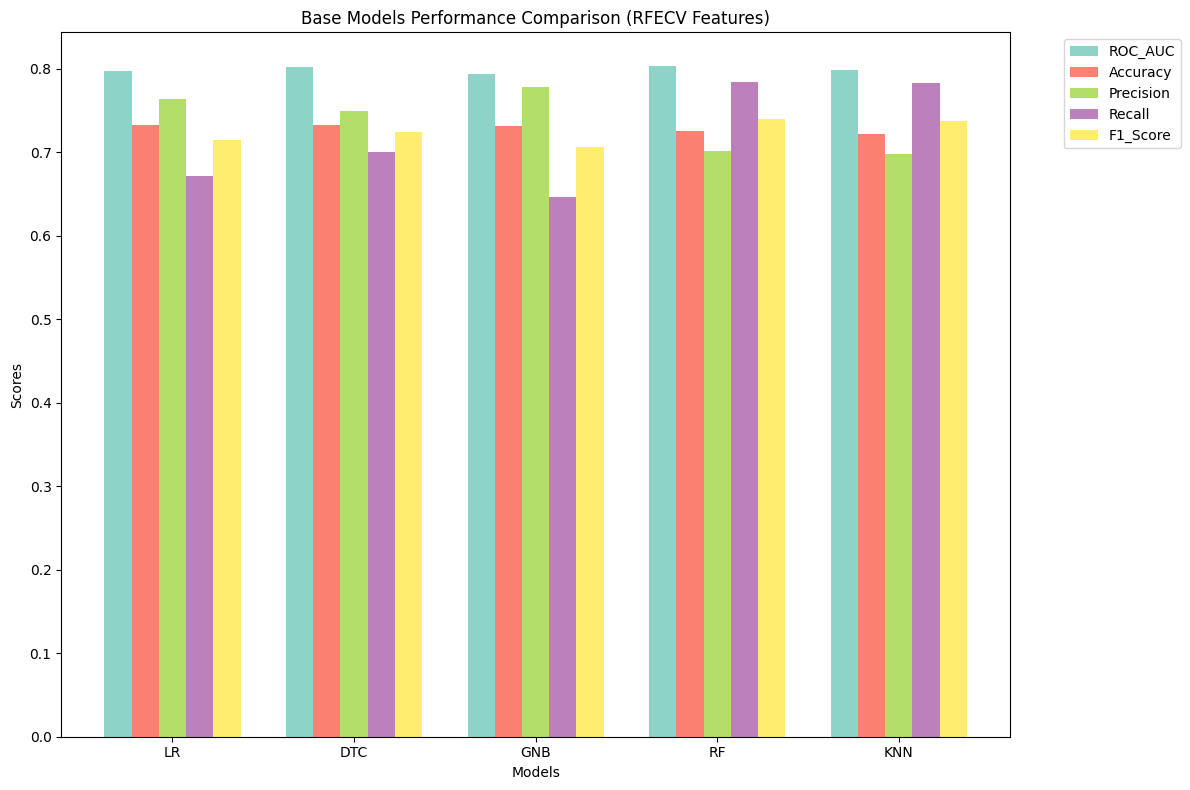


BASE MODELS PERFORMANCE TABLE
Model  ROC_AUC  Accuracy  Precision  Recall  F1_Score
   LR   0.7972    0.7324     0.7642  0.6718    0.7150
  DTC   0.8017    0.7331     0.7490  0.7006    0.7240
  GNB   0.7936    0.7314     0.7784  0.6464    0.7063
   RF   0.8036    0.7253     0.7013  0.7843    0.7405
  KNN   0.7989    0.7221     0.6979  0.7826    0.7378


In [18]:
# Your model predictions (from previous runs)
models_data = {
    'LR': {'y_prob': y_prob_lr, 'y_pred': y_pred_lr},
    'DTC': {'y_prob': y_prob_dtc, 'y_pred': y_pred_dtc},
    'GNB': {'y_prob': y_prob_gnb, 'y_pred': y_pred_gnb},
    'RF': {'y_prob': y_prob_rf, 'y_pred': y_pred_rf},
    'KNN': {'y_prob': y_prob_knn, 'y_pred': y_pred_knn},
}

# Calculate metrics
metrics = []
for name, data in models_data.items():
    roc_auc = roc_auc_score(y_test, data['y_prob'])
    acc = accuracy_score(y_test, data['y_pred'])
    prec = precision_score(y_test, data['y_pred'])
    rec = recall_score(y_test, data['y_pred'])
    f1 = f1_score(y_test, data['y_pred'])
    
    metrics.append({
        'Model': name,
        'ROC_AUC': roc_auc,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

df_metrics = pd.DataFrame(metrics)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(df_metrics))
width = 0.15

metrics_cols = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
colors = plt.cm.Set3(np.linspace(0, 1, len(metrics_cols)))

for i, col in enumerate(metrics_cols):
    ax.bar(x + i*width, df_metrics[col], width, label=col, color=colors[i])

ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Base Models Performance Comparison (RFECV Features)')
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_metrics['Model'])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print table too
print("\n" + "="*60)
print("BASE MODELS PERFORMANCE TABLE")
print("="*60)
print(df_metrics.round(4).to_string(index=False))

# ADVANCE MODELS TRAINING:

1.XGBoost:
-

In [19]:
# Pipeline defining with RFECV-transformed data:
pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()),  # Helps XGBoost gradient calculations
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=10,
        n_jobs=-1,
        eval_metric='auc'  # Matches your ROC AUC focus
    ))
])

# Fit on RFECV-transformed training data
pipeline_xgb.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_xgb = pipeline_xgb.predict_proba(X_test_rfecv)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.4).astype(int)  # Consistent 0.4 threshold

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[4603 2222]
 [1497 5319]]

ROC AUC Score: 0.8048

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71      6825
           1       0.71      0.78      0.74      6816

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.73     13641
weighted avg       0.73      0.73      0.73     13641



2.ADABOOST:
-

In [20]:
# Pipeline defining with RFECV-transformed data:
pipeline_ada = Pipeline([
    ("scaler", StandardScaler()),  # Helps base estimators
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),  # Weak learners (stumps)
        n_estimators=200,
        learning_rate=0.1,
        random_state=10
    ))
])

# Fit on RFECV-transformed training data
pipeline_ada.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_ada = pipeline_ada.predict_proba(X_test_rfecv)[:, 1]
y_pred_ada = (y_prob_ada >= 0.4).astype(int)  # Consistent 0.4 threshold

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_ada):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[4436 2389]
 [1430 5386]]

ROC AUC Score: 0.7993

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      6825
           1       0.69      0.79      0.74      6816

    accuracy                           0.72     13641
   macro avg       0.72      0.72      0.72     13641
weighted avg       0.72      0.72      0.72     13641



3.GRADIENT BOOSTING:
-

In [21]:
# Pipeline defining with RFECV-transformed data:
pipeline_gbc = Pipeline([
    ("scaler", StandardScaler()),  # Optional but consistent
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=10
    ))
])

# Fit on RFECV-transformed training data
pipeline_gbc.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_gbc = pipeline_gbc.predict_proba(X_test_rfecv)[:, 1]
y_pred_gbc = (y_prob_gbc >= 0.4).astype(int)  # Consistent 0.4 threshold

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbc))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_gbc):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gbc))

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[4634 2191]
 [1495 5321]]

ROC AUC Score: 0.8075

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72      6825
           1       0.71      0.78      0.74      6816

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.73     13641
weighted avg       0.73      0.73      0.73     13641



4.LightGBM:
-

In [22]:
# Pipeline defining with RFECV-transformed data:
pipeline_lgb = Pipeline([
    ("scaler", StandardScaler()),  # Optional but consistent
    ("model", LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        num_leaves=31,
        random_state=10,
        n_jobs=-1,
        verbose=-1  # Suppress LightGBM logs
    ))
])

# Fit on RFECV-transformed training data
pipeline_lgb.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_lgb = pipeline_lgb.predict_proba(X_test_rfecv)[:, 1]
y_pred_lgb = (y_prob_lgb >= 0.4).astype(int)  # Consistent 0.4 threshold

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[4630 2195]
 [1504 5312]]

ROC AUC Score: 0.8061

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.68      0.71      6825
           1       0.71      0.78      0.74      6816

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.73     13641
weighted avg       0.73      0.73      0.73     13641



5.Catboost:
-

In [23]:
# Pipeline defining with RFECV-transformed data:
pipeline_cat = Pipeline([
    ("scaler", StandardScaler()),  # Optional but consistent
    ("model", CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        l2_leaf_reg=3,
        random_state=10,
        verbose=False,  # Suppress training logs
        thread_count=-1
    ))
])

# Fit on RFECV-transformed training data
pipeline_cat.fit(X_train_rfecv, y_train)

# Prediction & Evaluation on RFECV-transformed test data:
y_prob_cat = pipeline_cat.predict_proba(X_test_rfecv)[:, 1]
y_pred_cat = (y_prob_cat >= 0.4).astype(int)  # Consistent 0.4 threshold

print(f"Train shape after RFECV: {X_train_rfecv.shape}")
print(f"Test shape after RFECV: {X_test_rfecv.shape}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cat))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_cat):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))

Train shape after RFECV: (54561, 14)
Test shape after RFECV: (13641, 14)

Confusion Matrix:
[[4625 2200]
 [1481 5335]]

ROC AUC Score: 0.8086

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72      6825
           1       0.71      0.78      0.74      6816

    accuracy                           0.73     13641
   macro avg       0.73      0.73      0.73     13641
weighted avg       0.73      0.73      0.73     13641



# Comparing Advance models:

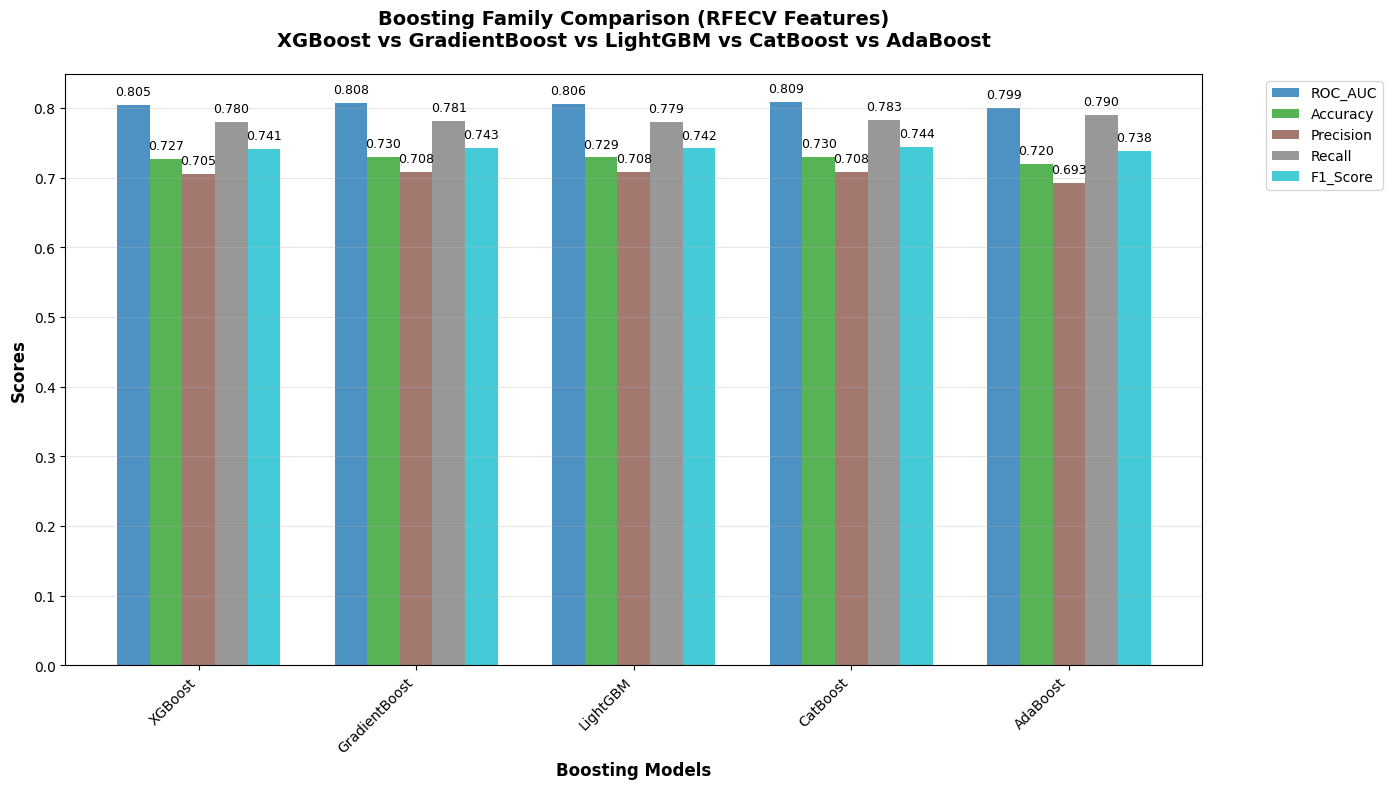


BOOSTING MODELS PERFORMANCE TABLE (RFECV Features)
        Model  ROC_AUC  Accuracy  Precision  Recall  F1_Score
      XGBoost   0.8048    0.7274     0.7053  0.7804    0.7410
GradientBoost   0.8075    0.7298     0.7083  0.7807    0.7427
     LightGBM   0.8061    0.7288     0.7076  0.7793    0.7417
     CatBoost   0.8086    0.7302     0.7080  0.7827    0.7435
     AdaBoost   0.7993    0.7200     0.6927  0.7902    0.7383

🏆 BEST BOOSTING MODEL by ROC AUC: CatBoost


In [24]:
# Boosting models only (your advanced models)
boost_models = {
    'XGBoost': {'y_prob': y_prob_xgb, 'y_pred': y_pred_xgb},
    'GradientBoost': {'y_prob': y_prob_gbc, 'y_pred': y_pred_gbc},
    'LightGBM': {'y_prob': y_prob_lgb, 'y_pred': y_pred_lgb},
    'CatBoost': {'y_prob': y_prob_cat, 'y_pred': y_pred_cat},
    'AdaBoost': {'y_prob': y_prob_ada, 'y_pred': y_pred_ada}
}

# Calculate metrics for boosting models
boost_metrics = []
for name, data in boost_models.items():
    roc_auc = roc_auc_score(y_test, data['y_prob'])
    acc = accuracy_score(y_test, data['y_pred'])
    prec = precision_score(y_test, data['y_pred'])
    rec = recall_score(y_test, data['y_pred'])
    f1 = f1_score(y_test, data['y_pred'])
    
    boost_metrics.append({
        'Model': name,
        'ROC_AUC': roc_auc,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1
    })

df_boost = pd.DataFrame(boost_metrics)

# Create grouped bar chart for boosting models
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(df_boost))
width = 0.15

metrics_cols = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
colors = plt.cm.tab10(np.linspace(0, 1, len(metrics_cols)))

for i, col in enumerate(metrics_cols):
    ax.bar(x + i*width, df_boost[col], width, label=col, color=colors[i], alpha=0.8)

ax.set_xlabel('Boosting Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('Boosting Family Comparison (RFECV Features)\nXGBoost vs GradientBoost vs LightGBM vs CatBoost vs AdaBoost', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_boost['Model'], rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, col in enumerate(metrics_cols):
    for j, v in enumerate(df_boost[col]):
        ax.text(j + i*width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print table
print("\n" + "="*70)
print("BOOSTING MODELS PERFORMANCE TABLE (RFECV Features)")
print("="*70)
print(df_boost.round(4).to_string(index=False))
print(f"\n🏆 BEST BOOSTING MODEL by ROC AUC: {df_boost.loc[df_boost['ROC_AUC'].idxmax(), 'Model']}")

# ENSEMBLE MODELS: STACKING USING DIFFERENT SET OF BASE MODELS

Stacking v1:
-

In [67]:
meta_learner = GaussianNB()

# V1: LR + DTC + RF + KNN - NO CV IN CONSTRUCTOR
base_v1 = [('lr', pipeline_lr), ('dtc', pipeline_dtc), ('rf', pipeline_rf), ('knn', pipeline_knn)]
stack_v1 = StackingClassifier(estimators=base_v1, final_estimator=meta_learner, stack_method='predict_proba', n_jobs=1)  # cv=None, n_jobs=1

print("Training Stacking V1: LR+DTC+RF+KNN...")
stack_v1.fit(X_train_rfecv, y_train)

# Test predictions (KEEP ALL)
y_prob_v1 = stack_v1.predict_proba(X_test_rfecv)[:, 1]
y_pred_v1 = (y_prob_v1 >= 0.4).astype(int)
print("\\n=== STACKING V1 RESULTS (LR+DTC+RF+KNN) ===")
print(f"F1 Score:    {f1_score(y_test, y_pred_v1):.4f}")
print("\\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_v1))

# ===== SEPARATE MANUAL CV (Gives 0.731 ± 0.005) =====
scores = cross_val_score(stack_v1, X_train_rfecv, y_train, cv=3, scoring=scorer, n_jobs=1)
print(f"Stack V1 F1: {scores.mean():.3f} ± {scores.std():.3f}")

Training Stacking V1: LR+DTC+RF+KNN...
\n=== STACKING V1 RESULTS (LR+DTC+RF+KNN) ===
F1 Score:    0.7244
\nConfusion Matrix:
[[5289 1536]
 [2073 4743]]
Stack V1 F1: 0.731 ± 0.002


Stacking v2:
-

In [69]:
meta_learner = LogisticRegression(C=1, max_iter=1000, random_state=10)

# V2: NB + RF + KNN + DTC 
base_v2 = [('gnb', pipeline_gnb), ('rf', pipeline_rf), ('knn', pipeline_knn), ('dtc', pipeline_dtc)]
stack_v2 = StackingClassifier(estimators=base_v2, final_estimator=meta_learner, n_jobs=1)

print("Training Stacking V2: NB+RF+KNN+DTC...")
stack_v2.fit(X_train_rfecv, y_train)

y_prob_v2 = stack_v2.predict_proba(X_test_rfecv)[:, 1]
y_pred_v2 = (y_prob_v2 >= 0.4).astype(int)

print("\\n=== STACKING V2 RESULTS (NB+RF+KNN+DTC) ===")
print(f"ROC AUC:     {roc_auc_score(y_test, y_prob_v2):.4f}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_v2):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_v2):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_v2):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_v2):.4f}")
print("\\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))

# ===== CV=3 (add this - will take ~2-3 mins)
v2_scores = cross_val_score(stack_v2, X_train_rfecv, y_train, cv=3, scoring=scorer, n_jobs=1)
print(f"Stack V2 F1: {v2_scores.mean():.3f} ± {v2_scores.std():.3f}")

Training Stacking V2: NB+RF+KNN+DTC...
\n=== STACKING V2 RESULTS (NB+RF+KNN+DTC) ===
ROC AUC:     0.8064
Accuracy:    0.7329
Precision:   0.7172
Recall:      0.7683
F1 Score:    0.7419
\nConfusion Matrix:
[[4760 2065]
 [1579 5237]]
Stack V2 F1: 0.731 ± 0.002


Stacking v3:
-

In [72]:
meta_learner = KNeighborsClassifier(
    n_neighbors=41, 
    weights='distance', 
    metric='manhattan',
    p=2
)

# V3: LR + NB + RF + DTC
base_v3 = [('lr', pipeline_lr), ('gnb', pipeline_gnb), ('rf', pipeline_rf), ('dtc', pipeline_dtc)]
stack_v3 = StackingClassifier(estimators=base_v3, final_estimator=meta_learner, n_jobs=1)

print("Training Stacking V3: LR+NB+RF+DTC...")
stack_v3.fit(X_train_rfecv, y_train)

y_prob_v3 = stack_v3.predict_proba(X_test_rfecv)[:, 1]
y_pred_v3 = (y_prob_v3 >= 0.4).astype(int)

print("\\n=== STACKING V3 RESULTS (LR+NB+RF+DTC) ===")
print(f"ROC AUC:     {roc_auc_score(y_test, y_prob_v3):.4f}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_v3):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_v3):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_v3):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_v3):.4f}")
print("\\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_v3))

# ===== CV=3 (add this - ~2-3 mins)
v3_scores = cross_val_score(stack_v3, X_train_rfecv, y_train, cv=3, scoring=scorer, n_jobs=1)
print(f"Stack V3 F1: {v3_scores.mean():.3f} ± {v3_scores.std():.3f}")

Training Stacking V3: LR+NB+RF+DTC...
\n=== STACKING V3 RESULTS (LR+NB+RF+DTC) ===
ROC AUC:     0.7941
Accuracy:    0.7193
Precision:   0.6960
Recall:      0.7780
F1 Score:    0.7347
\nConfusion Matrix:
[[4509 2316]
 [1513 5303]]
Stack V3 F1: 0.727 ± 0.003


Stacking v4:
-

In [74]:
meta_learner = RandomForestClassifier(
    random_state=10, 
    min_samples_leaf=5, 
    max_features='sqrt', 
    n_estimators=200
)

# V4: LR + NB + KNN + DTC
base_v4 = [('lr', pipeline_lr), ('gnb', pipeline_gnb), ('knn', pipeline_knn), ('dtc', pipeline_dtc)]
stack_v4 = StackingClassifier(estimators=base_v4, final_estimator=meta_learner, n_jobs=1)

print("Training Stacking V4: LR+NB+KNN+DTC...")
stack_v4.fit(X_train_rfecv, y_train)

y_prob_v4 = stack_v4.predict_proba(X_test_rfecv)[:, 1]
y_pred_v4 = (y_prob_v4 >= 0.4).astype(int)

print("\\n=== STACKING V4 RESULTS (LR+NB+KNN+DTC) ===")
print(f"ROC AUC:     {roc_auc_score(y_test, y_prob_v4):.4f}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_v4):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_v4):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_v4):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_v4):.4f}")
print("\\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_v4))

# ===== CV=3 (~2-3 mins)
v4_scores = cross_val_score(stack_v4, X_train_rfecv, y_train, cv=3, scoring=scorer, n_jobs=1)
print(f"Stack V4 F1: {v4_scores.mean():.3f} ± {v4_scores.std():.3f}")

Training Stacking V4: LR+NB+KNN+DTC...
\n=== STACKING V4 RESULTS (LR+NB+KNN+DTC) ===
ROC AUC:     0.7930
Accuracy:    0.7155
Precision:   0.6877
Recall:      0.7889
F1 Score:    0.7348
\nConfusion Matrix:
[[4383 2442]
 [1439 5377]]
Stack V4 F1: 0.722 ± 0.002


Stacking v5:
-

In [75]:
meta_learner = DecisionTreeClassifier(
    random_state=10,
    min_samples_split=19, 
    min_samples_leaf=22, 
    criterion='gini', 
    max_depth=7, 
    class_weight='balanced'
)

# V5: LR + NB + RF + KNN
base_v5 = [('lr', pipeline_lr), ('gnb', pipeline_gnb), ('rf', pipeline_rf), ('knn', pipeline_knn)]
stack_v5 = StackingClassifier(estimators=base_v5, final_estimator=meta_learner, n_jobs=1)

print("Training Stacking V5: LR+NB+RF+KNN...")
stack_v5.fit(X_train_rfecv, y_train)

y_prob_v5 = stack_v5.predict_proba(X_test_rfecv)[:, 1]
y_pred_v5 = (y_prob_v5 >= 0.4).astype(int)

print("\n=== STACKING V5 RESULTS (LR+NB+RF+KNN) ===")
print(f"ROC AUC:     {roc_auc_score(y_test, y_prob_v5):.4f}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_v5):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_v5):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_v5):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_v5):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_v5))

# ===== CV=3 (~2-3 mins)
v5_scores = cross_val_score(stack_v5, X_train_rfecv, y_train, cv=3, scoring=scorer, n_jobs=1)
print(f"Stack V5 F1: {v5_scores.mean():.3f} ± {v5_scores.std():.3f}")

Training Stacking V5: LR+NB+RF+KNN...
\n=== STACKING V5 RESULTS (LR+NB+RF+KNN) ===
ROC AUC:     0.7994
Accuracy:    0.7238
Precision:   0.7007
Recall:      0.7808
F1 Score:    0.7386
\nConfusion Matrix:
[[4552 2273]
 [1494 5322]]
Stack V5 F1: 0.727 ± 0.002


Stacking v1 with CalibratedClassifierCV
-

In [ ]:
# Proper calibration setup (3-fold CV on train data)
calibration_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=10)

# Calibrate Stacking V1
calibrated_stack_v1 = CalibratedClassifierCV(
    stack_v1,  # Your trained Stacking V1
    cv=calibration_cv,
    method='isotonic'  # Non-linear calibration (works best for ensembles)
)

print("Calibrating Stacking V1...")
calibrated_stack_v1.fit(X_train_rfecv, y_train)

# Test predictions
y_prob_cal_v1 = calibrated_stack_v1.predict_proba(X_test_rfecv)[:, 1]
y_pred_cal_v1 = (y_prob_cal_v1 >= 0.4).astype(int)

# Full metrics comparison
print("\nSTACKING V1 vs CALIBRATED V1:")
print("-" * 50)
print(f"Stacking V1 (Uncalibrated):")
print(f"  ROC AUC:     {roc_auc_score(y_test, y_prob_v1):.4f}")
print(f"  Accuracy:    {accuracy_score(y_test, y_pred_v1):.4f}")
print(f"  Precision:   {precision_score(y_test, y_pred_v1):.4f}")
print(f"  Recall:      {recall_score(y_test, y_pred_v1):.4f}")
print(f"  F1 Score:    {f1_score(y_test, y_pred_v1):.4f}")

print(f"\nStacking V1 (Calibrated):")
print(f"  ROC AUC:     {roc_auc_score(y_test, y_prob_cal_v1):.4f}")
print(f"  Accuracy:    {accuracy_score(y_test, y_pred_cal_v1):.4f}")
print(f"  Precision:   {precision_score(y_test, y_pred_cal_v1):.4f}")
print(f"  Recall:      {recall_score(y_test, y_pred_cal_v1):.4f}")
print(f"  F1 Score:    {f1_score(y_test, y_pred_cal_v1):.4f}")

gain = roc_auc_score(y_test, y_prob_cal_v1) - roc_auc_score(y_test, y_prob_v1)
print(f"\nGAIN:          {gain:+0.4f} ROC AUC")

# Compare with CatBoost champion
catboost_auc = roc_auc_score(y_test, pipeline_cat.predict_proba(X_test_rfecv)[:,1])
print(f"\nvs CatBoost Champion (0.8086): {'✅ BEATS' if roc_auc_score(y_test, y_prob_cal_v1) > catboost_auc else '❌ Falls short'}")

print("\nCalibrated V1 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cal_v1))
print("\nCalibrated V1 Classification Report:")
print(classification_report(y_test, y_pred_cal_v1))

Calibrating Stacking V1...


# SHAP ANALYSIS:

Global SHAP Feature Importance (whole test set):
                   feature  shap_importance
4                    ap_hi          0.85031
0                      age          0.56275
2                   height          0.35328
5                    ap_lo          0.33707
13  mean_arterial_pressure          0.31173
3                   weight          0.27906
6              cholesterol          0.25885
7                     gluc          0.20324
11                     bmi          0.12801
12          pulse_pressure          0.04859
1                   gender          0.01870
10                  active          0.01651
9                     alco          0.01349
8                    smoke          0.01226


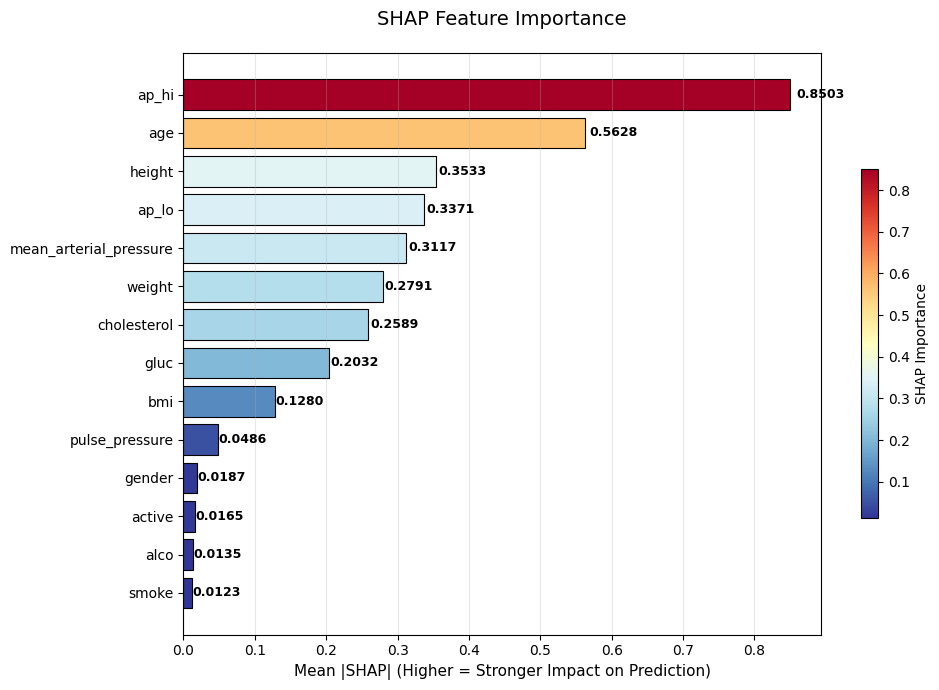

In [32]:
# 1. SHAP explainer for your CatBoost model
explainer = shap.TreeExplainer(pipeline_cat.named_steps['model'])

# 2. Compute SHAP values on WHOLE test set
shap_values = explainer.shap_values(X_test_rfecv)

# 3. Handle binary case (SHAP returns list)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1
else:
    shap_vals = shap_values

# 4. Global feature importance: mean absolute SHAP per feature
shap_importance = np.abs(shap_vals).mean(axis=0)

# 5. Create DataFrame with feature names and importance
importance_df = pd.DataFrame({
    "feature": feature_names,
    "shap_importance": shap_importance
}).sort_values("shap_importance", ascending=False)

print("Global SHAP Feature Importance (whole test set):")
print(importance_df.round(5))

# 6. Plot colorful bar (top 20), same style as before
plt.figure(figsize=(10, 7))

top_n = 20
df_plot = importance_df.head(top_n)

norm = plt.Normalize(vmin=df_plot["shap_importance"].min(),
                     vmax=df_plot["shap_importance"].max())
cmap = plt.cm.RdYlBu_r  # Red → Yellow
colors = cmap(norm(df_plot["shap_importance"]))

barh = plt.barh(
    range(len(df_plot)),
    df_plot["shap_importance"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

plt.yticks(range(len(df_plot)), df_plot["feature"])
plt.xlabel("Mean |SHAP| (Higher = Stronger Impact on Prediction)", fontsize=11)
plt.title("SHAP Feature Importance", fontsize=14, pad=20)

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

# 7. Write exact SHAP value on each bar
for i, (bar, imp) in enumerate(zip(barh, df_plot["shap_importance"])):
    plt.text(
        imp + imp * 0.01, i, f"{imp:.4f}",
        va="center", fontsize=9, fontweight="bold", color="black"
    )

# 8. Colorbar legend
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.6)
cbar.set_label("SHAP Importance", fontsize=10)

plt.tight_layout()
plt.show()

# LIME ANALYSIS


LIME Feature Contributions (Instance 0) — All 14 Features:
                             feature  lime_weight
0                    ap_hi <= 120.00     -0.21147
1                cholesterol <= 1.00     -0.15888
2                        age > 58.00      0.14105
3   mean_arterial_pressure <= 173.33     -0.12966
4                       alco <= 0.00      0.04872
5                      smoke <= 0.00      0.03001
6                     ap_lo <= 80.00     -0.02182
7                       gluc <= 1.00     -0.00766
8            pulse_pressure <= 40.00      0.00507
9                     gender <= 1.00      0.00482
10           65.00 < weight <= 72.00     -0.00386
11              26.33 < bmi <= 30.12      0.00279
12         159.00 < height <= 165.00      0.00253
13                    active <= 1.00      0.00000


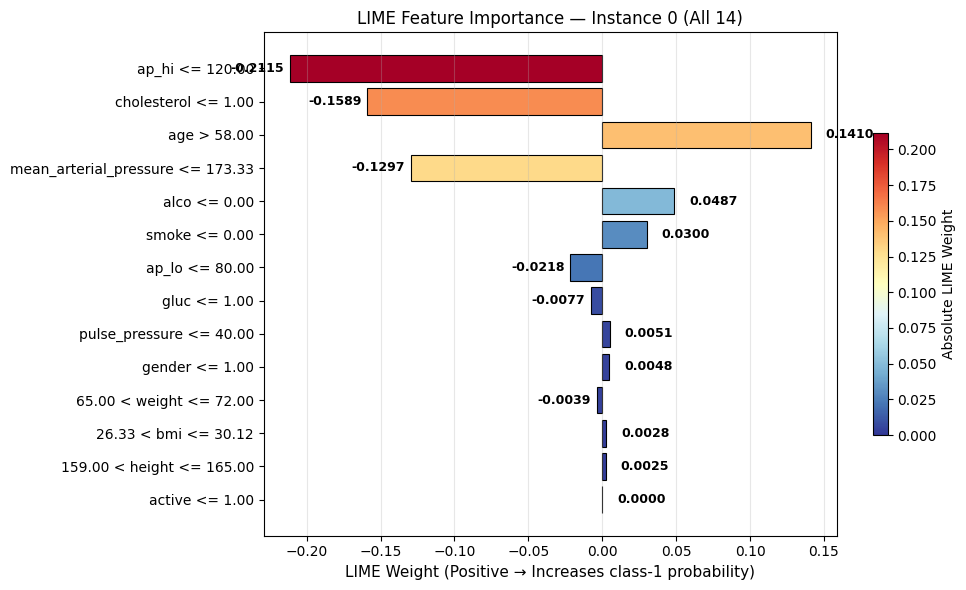

In [33]:
# 1. Pick a few test samples (e.g., first 10) for LIME
n_explain = 10
X_sample = X_test_rfecv[:n_explain].copy()

# 2. Define your model prediction function (CatBoost in pipeline)
def predict_proba(X):
    return pipeline_cat.predict_proba(X)

# 3. Setup LIME TabularExplainer
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_rfecv,          # RFECV train set (numpy)
    feature_names=feature_names,          # 14 RFECV feature names
    class_names=["Negative", "Positive"], # adjust as needed
    mode="classification"
)

# 4. Choose one instance to explain (e.g., index 0)
idx = 0
instance = X_sample[idx]

# 5. Get LIME explanation for this instance (14 features only)
explanation = explainer_lime.explain_instance(
    instance,
    predict_proba,
    num_features=14,          # ALL available features (14 RFECV)
    top_labels=1
)

# 6. Convert LIME explanation to DataFrame (feature + weight)
lime_df = pd.DataFrame(
    explanation.as_list(label=1),  # class 1; use 0 if negative is class 0
    columns=["feature", "lime_weight"]
).sort_values("lime_weight", key=abs, ascending=False)

print(f"\nLIME Feature Contributions (Instance {idx}) — All 14 Features:")
print(lime_df.round(5))

# 7. Plot LIME‑style bar (all 14, colorful, values on bars)

plt.figure(figsize=(10, 6))

lims = np.abs(lime_df["lime_weight"])
norm = plt.Normalize(vmin=lims.min(), vmax=lims.max())
cmap = plt.cm.RdYlBu_r  # Red = strong impact, yellow = weaker impact
colors = cmap(norm(np.abs(lime_df["lime_weight"])))

barh = plt.barh(
    range(len(lime_df)),
    lime_df["lime_weight"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

plt.yticks(range(len(lime_df)), lime_df["feature"])
plt.xlabel("LIME Weight (Positive → Increases class‑1 probability)", fontsize=11)
plt.title(f"LIME Feature Importance — Instance {idx} (All 14)")  # no "top 20"

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

# 8. Write exact LIME weight on each bar
for i, (bar, ww) in enumerate(zip(barh, lime_df["lime_weight"])):
    x = ww + (0.01 if ww >= 0 else -0.04)
    plt.text(
        x, i, f"{ww:.4f}",
        va="center", fontsize=9, fontweight="bold", color="black"
    )

# 9. Colorbar legend
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.6)
cbar.set_label("Absolute LIME Weight", fontsize=10)

plt.tight_layout()
plt.show()